In [1]:
import pandas as pd

In [2]:
df = pd.read_parquet("../data/raw/train-00000-of-00001.parquet")

In [3]:
df.head()

,text,label
0,"Viernes Santo, de Pasión y día especial de la ...",0
1,El profeta Daniel fue uno de los principales p...,9
2,La compañía israelí UVisión ha llegado a un ac...,5
3,Escribano Mechanical & Engineering participa p...,5
4,Para aquellos que estén buscando una buena alt...,11


In [4]:
df.shape

(2048, 2)

In [5]:
df.columns

Index(['text', 'label'], dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2048 entries, 0 to 2047
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   text    2048 non-null   str  
 1   label   2048 non-null   int64
dtypes: int64(1), str(1)
memory usage: 8.5 MB


In [7]:
df["label"].value_counts().sort_index()

label
0     170
1     171
2     171
3     171
4     171
5     170
6     171
7     170
8     171
9     171
10    170
11    171
Name: count, dtype: int64

In [8]:
df.isna().sum()

text     0
label    0
dtype: int64

In [9]:
(df["text"].str.strip() == "").sum()

np.int64(0)

In [10]:
df.duplicated(subset=["text"]).sum()

np.int64(0)

In [11]:
print(df["text"].iloc[0])

Viernes Santo, de Pasión y día especial de la Semana Santa; muchos estarán preparándose para el colofón de esta Pascua mientras que otros llevarán ya unos afortunados días de descanso vacacional. No queremos aguarle la fiesta a nadie, pero el lunes arranca una nueva semana de vuelta a la rutina, y pensar en el menú semanal próximo es una buena manera de aprovechar este fin de semana festivo.En realidad no será tan traumático el fin de la Semana Santa, pues el mismo Lunes de Pascua en algunas zonas se estarán alargando las fiestas comiendo monas, y en Murcia arranca su semana grande con las Fiestas de Primavera. Así que, en nuestra propuesta de menú, incluimos recetas muy primaverales acordes con esta época, con un pequeño homenaje al recetario murciano, que para algo es mi tierra -y hay nostalgia acumulada-.Las fiestas son de Murcia pero nuestra gastronomía no sería lo mismo sin el aporte de otras zonas, especialmente con el litoral costero, el mar Menor y Cartagena, sus ya casi univer

In [12]:
sample = df.sample(20, random_state=42)

sample.to_csv(
    "../data/sample/spanish_news_sample.csv",
    index=False
)

In [13]:
label_map = {
    0: "tech",
    1: "play",
    2: "sport",
    3: "politics",
    4: "economy",
    5: "motor",
    6: "alimentation",
    7: "military",
    8: "fashion",
    9: "astronomy",
    10: "religion",
    11: "medicine"
}

df["category"] = df["label"].map(label_map)

df.head()

,text,label,category
0,"Viernes Santo, de Pasión y día especial de la ...",0,tech
1,El profeta Daniel fue uno de los principales p...,9,astronomy
2,La compañía israelí UVisión ha llegado a un ac...,5,motor
3,Escribano Mechanical & Engineering participa p...,5,motor
4,Para aquellos que estén buscando una buena alt...,11,medicine


In [14]:
for label in sorted(df["label"].unique()):
    print("\n" + "="*80)
    print("LABEL:", label)
    print("="*80)
    
    ejemplos = df[df["label"] == label]["text"].head(3)
    
    for i, texto in enumerate(ejemplos, 1):
        print(f"\nEjemplo {i}:")
        print(texto[:500])


LABEL: 0

Ejemplo 1:
Viernes Santo, de Pasión y día especial de la Semana Santa; muchos estarán preparándose para el colofón de esta Pascua mientras que otros llevarán ya unos afortunados días de descanso vacacional. No queremos aguarle la fiesta a nadie, pero el lunes arranca una nueva semana de vuelta a la rutina, y pensar en el menú semanal próximo es una buena manera de aprovechar este fin de semana festivo.En realidad no será tan traumático el fin de la Semana Santa, pues el mismo Lunes de Pascua en algunas zon

Ejemplo 2:
Kpop, churros, Blackpink, chocolate caliente… Casi todo lo que se encuadra en esas cuatro palabras tiene poco o nada que ver. Hasta que encontramos que la cantante surcoreana Jisoo —integrante del grupo de kpop Blackpink— se enamoró perdidamente en 2022 de los churros de un establecimiento barcelonés.Sin pretenderlo —imaginamos—, la cantante ha convertido una coqueta churrería situada en el corazón del Barrio Gótico de la Ciudad Condal en una meca gastronómica 

In [15]:
if "category" in df.columns:
    df = df.drop(columns=["category"])

df.head()

,text,label
0,"Viernes Santo, de Pasión y día especial de la ...",0
1,El profeta Daniel fue uno de los principales p...,9
2,La compañía israelí UVisión ha llegado a un ac...,5
3,Escribano Mechanical & Engineering participa p...,5
4,Para aquellos que estén buscando una buena alt...,11


In [16]:
pip install datasets


[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [17]:
from datasets import load_dataset

source_dataset = load_dataset(
    "mteb/spanish_news",
    split="train"
)

source_dataset

Dataset({
    features: ['language', 'label', 'newspaper', 'hash', 'text'],
    num_rows: 8099
})

In [18]:
source_dataset.features

{'language': Value('string'),
 'label': ClassLabel(names=['tech', 'play', 'sport', 'politics', 'economy', 'motor', 'alimentation', 'military', 'fashion', 'astronomy', 'religion', 'medicine']),
 'newspaper': Value('string'),
 'hash': Value('string'),
 'text': Value('string')}

In [19]:
source_dataset.features["label"]

ClassLabel(names=['tech', 'play', 'sport', 'politics', 'economy', 'motor', 'alimentation', 'military', 'fashion', 'astronomy', 'religion', 'medicine'])

In [20]:
from datasets import load_dataset

source_dataset = load_dataset(
    "mteb/spanish_news",
    split="test"
)

source_dataset

Dataset({
    features: ['language', 'label', 'newspaper', 'hash', 'text'],
    num_rows: 2048
})

In [21]:
label_names = source_dataset.features["label"].names

label_names

['tech',
 'play',
 'sport',
 'politics',
 'economy',
 'motor',
 'alimentation',
 'military',
 'fashion',
 'astronomy',
 'religion',
 'medicine']

In [22]:
source_df = source_dataset.to_pandas()

source_df.head()

,language,label,newspaper,hash,text
0,es,8,mujer_hoy,4e8fadf471b56e84be4cc93cf31290d0af257d4f,"Hay celebrities que pase el tiempo que pase, ..."
1,es,9,wired,122af6e2f9a4418c14b76b857dfbf683824f0346,El cáncer de pulmón ha emergido como la princi...
2,es,6,directo_al_paladar,f2c496348fb63ebadd489bdc00ffc11710e980f9,Nuestro país tiene una merecida fama de ser un...
3,es,6,directo_al_paladar,2da7dd115bed841e3130c3b9c0d1c2d1df56e8c0,La oferta de utensilios y herramientas culinar...
4,es,4,diario_de_sevilla,bddc6d7449c65d81dde4dfad2079ffbeadc01200,Las movilizaciones agrarias han llegado a su ...


In [23]:
source_df["source_category"] = source_df["label"].apply(
    lambda x: label_names[x]
)

source_df[["text", "label", "source_category"]].head()

,text,label,source_category
0,"Hay celebrities que pase el tiempo que pase, ...",8,fashion
1,El cáncer de pulmón ha emergido como la princi...,9,astronomy
2,Nuestro país tiene una merecida fama de ser un...,6,alimentation
3,La oferta de utensilios y herramientas culinar...,6,alimentation
4,Las movilizaciones agrarias han llegado a su ...,4,economy


In [24]:
matched = df.merge(
    source_df[["text", "source_category"]],
    on="text",
    how="left"
)

matched.head()

,text,label,source_category
0,"Viernes Santo, de Pasión y día especial de la ...",0,NaN
1,El profeta Daniel fue uno de los principales p...,9,religion
2,La compañía israelí UVisión ha llegado a un ac...,5,NaN
3,Escribano Mechanical & Engineering participa p...,5,NaN
4,Para aquellos que estén buscando una buena alt...,11,NaN


In [25]:
matched["source_category"].isna().sum()

np.int64(1620)

In [26]:
mapping_table = (
    matched.dropna(subset=["source_category"])
    .groupby(["label", "source_category"])
    .size()
    .reset_index(name="count")
    .sort_values(["label", "count"], ascending=[True, False])
)

mapping_table

,label,source_category,count
0,0,alimentation,36
1,1,astronomy,36
2,2,economy,42
3,2,tech,1
4,3,fashion,41
5,4,medicine,38
6,5,military,34
7,6,motor,37
8,7,play,32
9,8,politics,33


In [27]:
best_mapping = (
    mapping_table
    .sort_values(["label", "count"], ascending=[True, False])
    .drop_duplicates("label")
    [["label", "source_category", "count"]]
)

best_mapping

,label,source_category,count
0,0,alimentation,36
1,1,astronomy,36
2,2,economy,42
4,3,fashion,41
5,4,medicine,38
6,5,military,34
7,6,motor,37
8,7,play,32
9,8,politics,33
10,9,religion,32


In [28]:
correct_mapping = dict(
    zip(
        best_mapping["label"],
        best_mapping["source_category"]
    )
)

correct_mapping

{0: 'alimentation',
 1: 'astronomy',
 2: 'economy',
 3: 'fashion',
 4: 'medicine',
 5: 'military',
 6: 'motor',
 7: 'play',
 8: 'politics',
 9: 'religion',
 10: 'sport',
 11: 'tech'}

In [29]:
df["category"] = df["label"].map(correct_mapping)

df[["label", "category"]].drop_duplicates().sort_values("label")

,label,category
0,0,alimentation
11,1,astronomy
27,2,economy
13,3,fashion
14,4,medicine
2,5,military
20,6,motor
8,7,play
5,8,politics
1,9,religion


In [30]:
best_mapping


,label,source_category,count
0,0,alimentation,36
1,1,astronomy,36
2,2,economy,42
4,3,fashion,41
5,4,medicine,38
6,5,military,34
7,6,motor,37
8,7,play,32
9,8,politics,33
10,9,religion,32


In [31]:
pd.crosstab(
    matched["label"],
    matched["source_category"]
)

source_category,alimentation,astronomy,economy,fashion,medicine,military,motor,play,politics,religion,sport,tech
label,,,,,,,,,,,,
0,36,0,0,0,0,0,0,0,0,0,0,0
1,0,36,0,0,0,0,0,0,0,0,0,0
2,0,0,42,0,0,0,0,0,0,0,0,1
3,0,0,0,41,0,0,0,0,0,0,0,0
4,0,0,0,0,38,0,0,0,0,0,0,0
5,0,0,0,0,0,34,0,0,0,0,0,0
6,0,0,0,0,0,0,37,0,0,0,0,0
7,0,0,0,0,0,0,0,32,0,0,0,0
8,0,0,0,0,0,0,0,0,33,0,0,0


In [32]:
correct_mapping = {
    0: "alimentation",
    1: "astronomy",
    2: "economy",
    3: "fashion",
    4: "medicine",
    5: "military",
    6: "motor",
    7: "play",
    8: "politics",
    9: "religion",
    10: "sport",
    11: "tech"
}

In [33]:
df["category"] = df["label"].map(correct_mapping)

df[["label", "category"]].drop_duplicates().sort_values("label")

,label,category
0,0,alimentation
11,1,astronomy
27,2,economy
13,3,fashion
14,4,medicine
2,5,military
20,6,motor
8,7,play
5,8,politics
1,9,religion


In [34]:
df["category"].value_counts().sort_index()

category
alimentation    170
astronomy       171
economy         171
fashion         171
medicine        171
military        170
motor           171
play            170
politics        171
religion        171
sport           170
tech            171
Name: count, dtype: int64

### Recuperación de las categorías

El corpus `SpanishNewsClassification` conserva las categorías como etiquetas
numéricas (0-11), sin incluir directamente el nombre de cada categoría.

Para recuperar su significado, se cruzaron los textos del corpus con el
dataset fuente `mteb/spanish_news`, que conserva las categorías originales.

Se encontraron coincidencias exactas para una parte del corpus. Estas
coincidencias permitieron identificar de forma consistente la correspondencia
entre cada etiqueta numérica y su categoría temática.

El mapeo obtenido fue:

- 0: alimentation
- 1: astronomy
- 2: economy
- 3: fashion
- 4: medicine
- 5: military
- 6: motor
- 7: play
- 8: politics
- 9: religion
- 10: sport
- 11: tech


In [35]:
df["n_palabras"] = df["text"].str.split().str.len()

df["n_palabras"].describe()

count     2048.000000
mean       682.081543
std        816.214115
min         80.000000
25%        361.750000
50%        539.000000
75%        837.000000
max      29746.000000
Name: n_palabras, dtype: float64

In [36]:
df.groupby("category")["n_palabras"].agg(
    ["count", "mean", "median", "min", "max"]
).round(1)

,count,mean,median,min,max
category,,,,,
alimentation,170,702.6,507.0,182,2741
astronomy,171,471.5,412.0,81,2195
economy,171,560.1,516.0,125,1600
fashion,171,510.1,449.0,90,1925
medicine,171,1287.5,958.0,216,29746
military,170,976.6,782.5,80,5621
motor,171,619.4,545.0,161,1906
play,170,528.2,367.0,95,1683
politics,171,607.4,513.0,133,2615


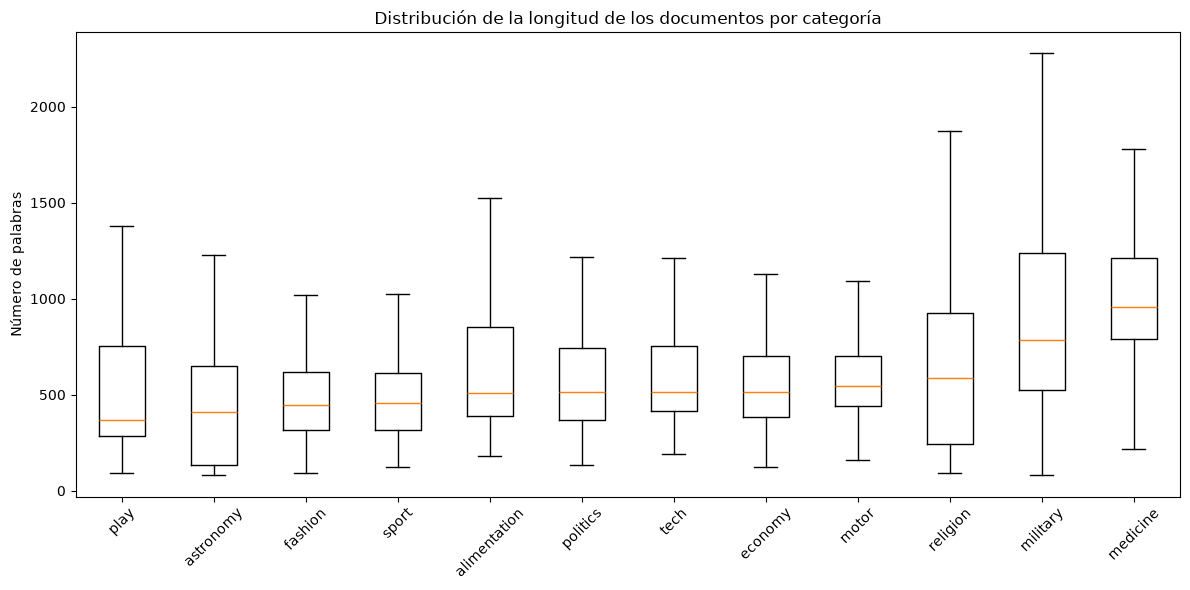

In [37]:
import matplotlib.pyplot as plt

orden = (
    df.groupby("category")["n_palabras"]
    .median()
    .sort_values()
    .index
)

datos_boxplot = [
    df.loc[df["category"] == categoria, "n_palabras"]
    for categoria in orden
]

plt.figure(figsize=(12, 6))

plt.boxplot(
    datos_boxplot,
    tick_labels=orden,
    showfliers=False
)

plt.xticks(rotation=45)
plt.ylabel("Número de palabras")
plt.title("Distribución de la longitud de los documentos por categoría")
plt.tight_layout()
plt.show()

In [38]:
df.sort_values("n_palabras", ascending=False)[
    ["category", "n_palabras", "text"]
].head(10)

,category,n_palabras,text
1160,medicine,29746,Dispositivos de asistencia ventricular de larg...
203,military,5621,El tercer trimestre de 2020 viene principalme...
1197,medicine,5322,Comportamiento de la CK-MB y la troponina T en...
1809,tech,4406,"En 2017 Roger Guasch encajó un golpe duro, de ..."
1604,medicine,3970,Artículo de revisión. Rinitis alérgicaDra. Mar...
1504,medicine,3670,Una visión universal del infarto del miocardio...
1684,military,3511,Con siete clientes internacionales además de l...
413,medicine,3506,Trabajo de Revisión. Trastornos hipertensivos ...
958,religion,3332,Han preguntado al Papa Francisco en la revista...
854,military,3324,La historia del dibujo técnico se remonta a mu...


In [39]:
outlier = df.sort_values("n_palabras", ascending=False).iloc[0]

print("Categoría:", outlier["category"])
print("Número de palabras:", outlier["n_palabras"])
print(outlier["text"])

Categoría: medicine
Número de palabras: 29746
Dispositivos de asistencia ventricular de larga duración, el inicio del futuroLos dispositivos de asistencia ventricular (DAV) son el inicio del futuro. Hoy en día, una persona puede sobrevivir a la muerte o mejorar drásticamente su calidad de vida gracias a una máquina que puede llevar por la calle a modo de bandolera mientras espera un trasplante de corazón.Autores: Torres Ferrer, A; Sánchez Cobacho, MC; Ayarza Garza, G; Prieto Alejandre, L; Gamarro Cano, Y; Tortosa Herraiz,S ; Sarra Marti, J.Muchos pacientes no superan esta espera, el puente al trasplante, afortunadamente iniciamos un camino próspero gracias a la tecnología que nos permitirá no solamente pasar este puente, sino que estos dispositivos serán sustitutos de un corazón, es el inicio del ser biónico. Los DAV ofrecen una nueva esperanza de vida como alternativa al trasplante cardíaco. La principal causa es la  insuficiencia cardiaca (IC), factor que se ha convertido en epidemia

In [40]:
df["n_palabras"].quantile([0.90, 0.95, 0.99])

0.90    1215.30
0.95    1558.55
0.99    2769.09
Name: n_palabras, dtype: float64

In [41]:
(df["n_palabras"] > 5000).sum()

np.int64(3)

In [42]:
df[df["n_palabras"] > 5000][
    ["category", "n_palabras"]
].sort_values("n_palabras", ascending=False)

,category,n_palabras
1160,medicine,29746
203,military,5621
1197,medicine,5322


### Detección de documentos atípicos

El análisis de longitudes muestra una distribución con una cola derecha pronunciada.

- Percentil 90: 1.215 palabras
- Percentil 95: 1.559 palabras
- Percentil 99: 2.769 palabras

Solo 3 documentos superan las 5.000 palabras.

El caso más extremo pertenece a la categoría `medicine` y contiene 29.746 palabras.
Aunque su longitud es claramente atípica, el contenido inspeccionado es coherente con la
categoría médica, por lo que se conserva en esta fase y se documenta como una limitación
del corpus.

## 3. Preprocesamiento

El pipeline se aplica en el siguiente orden:

1. Tokenización
2. Conversión a minúsculas
3. Eliminación de stopwords, conservando negaciones
4. Lematización
5. Eliminación de puntuación y espacios


In [43]:
import spacy

nlp = spacy.load("es_core_news_sm")

In [44]:
ejemplo_texto = df.loc[df["n_palabras"].idxmin(), "text"]

print(ejemplo_texto)

foto: Sistema Xpeller Rapid  Armado en un 4x4foto: Sistema Xpeller Rapid  Armado en un 4x4foto: Sistema Xpeller Rapid  Armado en un 4x4foto: Xpeller Guard y Software CxEyefoto: Xpeller Guard y Software CxEyefoto: Xpeller Guard y Software CxEyefoto: Z: NightOwl ZM-ER thermal camerafoto: Z: NightOwl ZM-ER thermal camerafoto: Z: NightOwl ZM-ER thermal cameraZ: NightOwl ZM-ER thermal camerafoto: SPEXER® 2000 Security Radar for Border Surveillancefoto: SPEXER® 2000 Security Radar for Border Surveillancefoto: SPEXER® 2000 Security Radar for Border Surveillance


In [45]:
mediana = df["n_palabras"].median()

indice_ejemplo = (df["n_palabras"] - mediana).abs().idxmin()

ejemplo_texto = df.loc[indice_ejemplo, "text"]

print("Categoría:", df.loc[indice_ejemplo, "category"])
print("Número de palabras:", df.loc[indice_ejemplo, "n_palabras"])
print(ejemplo_texto)

Categoría: fashion
Número de palabras: 539
Lo primero que un buen podólogo recomienda en cualquier consulta es que es muy importante desterrar todo aquel calzado que nos aleje de la posición natural del pie si queremos mantener una buena salud plantar. Descartadas las zapatillas completamente planas de suela dura, toca ponerse a buscar aquellos zapatos que sean más anatómicos, flexibles y que nos ayuden a controlar la postura corporal. Ahora bien, esto no significa que tengamos que recurrir al típico calzado ortopédico voluminoso que está muy fuera de la moda y las tendencias actuales. Hay alternativas que nos sirven para llevar a diario con nuestra ropa más de vestir para ir a la oficina o incluso con otros pantalones más tipo sport que se adaptan a nuestro estilo y nos mantienen con la posición adecuada. Hablamos por ejemplo, de un tipo de zapatilla que los podólogos españoles siempre tienen en el radar por la calidad de sus materiales y la forma de la plantilla: algunos modelos de l

### 3.1 Tokenización

Se utiliza el tokenizador de spaCy para español (`es_core_news_sm`) porque
permite separar correctamente las unidades léxicas teniendo en cuenta las
características del idioma.

La tokenización se realiza antes del resto de transformaciones, ya que las
decisiones posteriores se aplican sobre cada token individual.

In [46]:
doc = nlp(ejemplo_texto)

tokens = [token.text for token in doc]

print(tokens[:50])

['Lo', 'primero', 'que', 'un', 'buen', 'podólogo', 'recomienda', 'en', 'cualquier', 'consulta', 'es', 'que', 'es', 'muy', 'importante', 'desterrar', 'todo', 'aquel', 'calzado', 'que', 'nos', 'aleje', 'de', 'la', 'posición', 'natural', 'del', 'pie', 'si', 'queremos', 'mantener', 'una', 'buena', 'salud', 'plantar', '.', 'Descartadas', 'las', 'zapatillas', 'completamente', 'planas', 'de', 'suela', 'dura', ',', 'toca', 'ponerse', 'a', 'buscar', 'aquellos']


### 3.2 Conversión a minúsculas

Los tokens se convierten a minúsculas para evitar que una misma palabra sea
tratada como términos diferentes por aparecer al inicio de una oración o con
mayúsculas.

El texto original se conserva sin modificar.

In [47]:
tokens_minusculas = [token.lower() for token in tokens]

print(tokens_minusculas[:50])

['lo', 'primero', 'que', 'un', 'buen', 'podólogo', 'recomienda', 'en', 'cualquier', 'consulta', 'es', 'que', 'es', 'muy', 'importante', 'desterrar', 'todo', 'aquel', 'calzado', 'que', 'nos', 'aleje', 'de', 'la', 'posición', 'natural', 'del', 'pie', 'si', 'queremos', 'mantener', 'una', 'buena', 'salud', 'plantar', '.', 'descartadas', 'las', 'zapatillas', 'completamente', 'planas', 'de', 'suela', 'dura', ',', 'toca', 'ponerse', 'a', 'buscar', 'aquellos']


### 3.3 Eliminación de stopwords

Se eliminan palabras funcionales muy frecuentes que aportan poca información
para distinguir la temática del documento.

Se conservan las negaciones `no`, `nunca`, `jamás` y `sin`, ya que pueden
cambiar el significado de una frase y podrían ser relevantes posteriormente
para el análisis de tono o sentimiento.

In [48]:
negaciones = {"no", "nunca", "jamás", "sin"}

tokens_sin_stopwords = [
    token.text.lower()
    for token in doc
    if not token.is_stop or token.text.lower() in negaciones
]

print(tokens_sin_stopwords[:50])

['podólogo', 'recomienda', 'consulta', 'importante', 'desterrar', 'calzado', 'aleje', 'posición', 'natural', 'pie', 'mantener', 'salud', 'plantar', '.', 'descartadas', 'zapatillas', 'completamente', 'planas', 'suela', 'dura', ',', 'toca', 'ponerse', 'buscar', 'zapatos', 'anatómicos', ',', 'flexibles', 'ayuden', 'controlar', 'postura', 'corporal', '.', ',', 'no', 'significa', 'tengamos', 'recurrir', 'típico', 'calzado', 'ortopédico', 'voluminoso', 'moda', 'tendencias', 'actuales', '.', 'alternativas', 'sirven', 'diario', 'ropa']


### 3.4 Lematización

Se utiliza lematización en lugar de stemming porque permite reducir distintas
formas flexionadas a una forma lingüísticamente interpretable.

Esto ayuda a reducir el tamaño del vocabulario sin perder tanto significado.

In [49]:
tokens_lematizados = [
    token.lemma_.lower()
    for token in doc
    if not token.is_stop or token.text.lower() in negaciones
]

print(tokens_lematizados[:50])

['podólogo', 'recomendar', 'consulta', 'importante', 'desterrar', 'calzado', 'alejar', 'posición', 'natural', 'pie', 'mantener', 'salud', 'plantar', '.', 'descartar', 'zapatilla', 'completamente', 'plano', 'suela', 'duro', ',', 'tocar', 'poner él', 'buscar', 'zapato', 'anatómico', ',', 'flexible', 'ayudar', 'controlar', 'postura', 'corporal', '.', ',', 'no', 'significar', 'tener', 'recurrir', 'típico', 'calzado', 'ortopédico', 'voluminoso', 'moda', 'tendencia', 'actual', '.', 'alternativa', 'servir', 'diario', 'ropa']


In [50]:
tokens_finales = [
    token.lemma_.lower()
    for token in doc
    if (
        (not token.is_stop or token.text.lower() in negaciones)
        and not token.is_punct
        and not token.is_space
    )
]

print(tokens_finales[:50])

['podólogo', 'recomendar', 'consulta', 'importante', 'desterrar', 'calzado', 'alejar', 'posición', 'natural', 'pie', 'mantener', 'salud', 'plantar', 'descartar', 'zapatilla', 'completamente', 'plano', 'suela', 'duro', 'tocar', 'poner él', 'buscar', 'zapato', 'anatómico', 'flexible', 'ayudar', 'controlar', 'postura', 'corporal', 'no', 'significar', 'tener', 'recurrir', 'típico', 'calzado', 'ortopédico', 'voluminoso', 'moda', 'tendencia', 'actual', 'alternativa', 'servir', 'diario', 'ropa', 'vestir', 'oficina', 'pantalón', 'tipo', 'sport', 'adaptar']


### 3.5 Puntuación, espacios y otros elementos

- La puntuación se elimina porque no es necesaria para el análisis temático.
- Los espacios se eliminan porque no constituyen unidades léxicas.
- Las mayúsculas se normalizan a minúsculas.
- Las cifras se conservan por ahora, ya que pueden aportar información
  relevante en categorías como economía, deporte, tecnología o medicina.
- Los emojis no se eliminan específicamente en esta fase; su presencia se
  analizará antes de decidir su tratamiento.

In [51]:
print("1. TOKENS ORIGINALES:")
print(tokens[:30])

print("\n2. MINÚSCULAS:")
print(tokens_minusculas[:30])

print("\n3. SIN STOPWORDS (conservando negaciones):")
print(tokens_sin_stopwords[:30])

print("\n4. LEMATIZACIÓN:")
print(tokens_lematizados[:30])

print("\n5. RESULTADO FINAL:")
print(tokens_finales[:30])

1. TOKENS ORIGINALES:
['Lo', 'primero', 'que', 'un', 'buen', 'podólogo', 'recomienda', 'en', 'cualquier', 'consulta', 'es', 'que', 'es', 'muy', 'importante', 'desterrar', 'todo', 'aquel', 'calzado', 'que', 'nos', 'aleje', 'de', 'la', 'posición', 'natural', 'del', 'pie', 'si', 'queremos']

2. MINÚSCULAS:
['lo', 'primero', 'que', 'un', 'buen', 'podólogo', 'recomienda', 'en', 'cualquier', 'consulta', 'es', 'que', 'es', 'muy', 'importante', 'desterrar', 'todo', 'aquel', 'calzado', 'que', 'nos', 'aleje', 'de', 'la', 'posición', 'natural', 'del', 'pie', 'si', 'queremos']

3. SIN STOPWORDS (conservando negaciones):
['podólogo', 'recomienda', 'consulta', 'importante', 'desterrar', 'calzado', 'aleje', 'posición', 'natural', 'pie', 'mantener', 'salud', 'plantar', '.', 'descartadas', 'zapatillas', 'completamente', 'planas', 'suela', 'dura', ',', 'toca', 'ponerse', 'buscar', 'zapatos', 'anatómicos', ',', 'flexibles', 'ayuden', 'controlar']

4. LEMATIZACIÓN:
['podólogo', 'recomendar', 'consulta', '

In [52]:
negaciones = {"no", "nunca", "jamás", "sin"}

def preprocess_text(text):
    doc = nlp(text)

    tokens_procesados = []

    for token in doc:
        if token.is_space:
            continue

        if token.is_punct:
            continue

        token_lower = token.text.lower()

        if token.is_stop and token_lower not in negaciones:
            continue

        lemma = token.lemma_.lower().strip()

        if lemma:
            tokens_procesados.append(lemma)

    return tokens_procesados

In [53]:
df["tokens_antes"] = df["text"].str.split()

In [54]:
df["tokens_despues"] = df["text"].apply(preprocess_text)

In [55]:
tokens_antes_total = df["tokens_antes"].apply(len).sum()
tokens_despues_total = df["tokens_despues"].apply(len).sum()

print("Tokens antes:", tokens_antes_total)
print("Tokens después:", tokens_despues_total)

Tokens antes: 1396903
Tokens después: 689489


In [56]:
vocabulario_antes = set(
    token.lower()
    for lista in df["tokens_antes"]
    for token in lista
)

vocabulario_despues = set(
    token
    for lista in df["tokens_despues"]
    for token in lista
)

print("Vocabulario antes:", len(vocabulario_antes))
print("Vocabulario después:", len(vocabulario_despues))

Vocabulario antes: 136252
Vocabulario después: 66091


In [57]:
resumen_preprocesamiento = pd.DataFrame({
    "Métrica": [
        "Tokens totales",
        "Tamaño del vocabulario"
    ],
    "Antes": [
        tokens_antes_total,
        len(vocabulario_antes)
    ],
    "Después": [
        tokens_despues_total,
        len(vocabulario_despues)
    ]
})

resumen_preprocesamiento

,Métrica,Antes,Después
0,Tokens totales,1396903,689489
1,Tamaño del vocabulario,136252,66091


### Impacto del preprocesamiento

El preprocesamiento reduce el número total de tokens y el tamaño del vocabulario
al eliminar stopwords, puntuación, espacios y al unificar formas flexionadas
mediante lematización.

Esta reducción facilita la comparación entre documentos y evita que distintas
formas de una misma palabra se traten como términos independientes.

### Impacto cuantitativo del preprocesamiento

El pipeline reduce los tokens totales de 1.396.903 a 689.489, una reducción aproximada del 50,6 %.

El tamaño del vocabulario pasa de 136.252 términos distintos a 66.091, lo que supone una reducción aproximada del 51,5 %.

La reducción se debe principalmente a la eliminación de stopwords y puntuación, así como a la normalización mediante minúsculas y lematización.

Esto permite trabajar con una representación textual más compacta y reduce la dispersión provocada por distintas formas flexionadas de una misma palabra.

In [58]:
from collections import Counter

todos_tokens = [
    token
    for lista in df["tokens_despues"]
    for token in lista
]

frecuencias = Counter(todos_tokens)

top_20 = frecuencias.most_common(20)

top_20

[('no', 9013),
 ('año', 3327),
 ('sin', 2385),
 ('sistema', 1919),
 ('paciente', 1381),
 ('forma', 1358),
 ('euros', 1313),
 ('tipo', 1281),
 ('caso', 1273),
 ('millón', 1179),
 ('poder', 1148),
 ('vida', 1141),
 ('tiempo', 1077),
 ('permitir', 1053),
 ('punto', 1026),
 ('equipo', 1019),
 ('españa', 996),
 ('llegar', 988),
 ('persona', 981),
 ('hora', 963)]

In [59]:
frecuencias_df = pd.DataFrame(
    top_20,
    columns=["termino", "frecuencia"]
)

frecuencias_df

,termino,frecuencia
0,no,9013
1,año,3327
2,sin,2385
3,sistema,1919
4,paciente,1381
5,forma,1358
6,euros,1313
7,tipo,1281
8,caso,1273
9,millón,1179


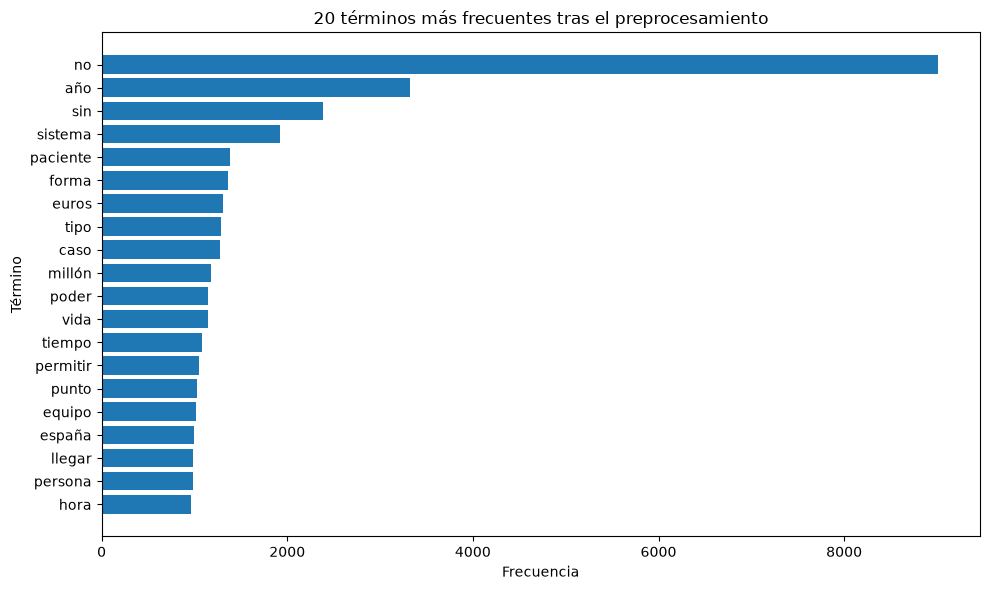

In [60]:
plt.figure(figsize=(10, 6))

plt.barh(
    frecuencias_df["termino"][::-1],
    frecuencias_df["frecuencia"][::-1]
)

plt.xlabel("Frecuencia")
plt.ylabel("Término")
plt.title("20 términos más frecuentes tras el preprocesamiento")
plt.tight_layout()
plt.show()

### Términos más frecuentes

Los términos más frecuentes después del preprocesamiento incluyen `no` y `sin`.
Su elevada frecuencia es esperable porque las negaciones se han conservado
deliberadamente durante el preprocesamiento.

Esta decisión evita perder información semántica relevante para análisis
posteriores de tono o sentimiento.

También aparecen términos relacionados con distintas temáticas del corpus,
como `paciente`, `sistema`, `euros` y `equipo`, lo que sugiere que las categorías
pueden presentar vocabularios diferenciados.

In [61]:
df["texto_procesado"] = df["tokens_despues"].apply(" ".join)

df[["category", "texto_procesado"]].head()

,category,texto_procesado
0,alimentation,viernes santo pasión especial semana santa est...
1,religion,profeta daniel principal profeta antiguo testa...
2,military,compañía israelí uvisión llegar alemana rheinm...
3,military,escribano mechanical engineering participar te...
4,tech,estar buscar alternativa famoso kindle amazon ...


In [62]:
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    tokenizer=str.split,
    preprocessor=None,
    token_pattern=None,
    lowercase=False,
    min_df=3
)

X_tfidf = vectorizer.fit_transform(df["texto_procesado"])

terminos = np.array(vectorizer.get_feature_names_out())

print("Forma de la matriz TF-IDF:", X_tfidf.shape)

Forma de la matriz TF-IDF: (2048, 16941)


In [63]:
def terminos_categoria(categoria, n=15):
    mascara = df["category"].eq(categoria).to_numpy()

    media_tfidf = np.asarray(
        X_tfidf[mascara].mean(axis=0)
    ).ravel()

    indices = media_tfidf.argsort()[::-1][:n]

    return pd.DataFrame({
        "termino": terminos[indices],
        "tfidf_medio": media_tfidf[indices]
    })

In [64]:
top_sport = terminos_categoria("sport", 15)
top_tech = terminos_categoria("tech", 15)

print("SPORT")
display(top_sport)

print("TECH")
display(top_tech)

SPORT


,termino,tfidf_medio
0,partido,0.081591
1,no,0.057059
2,equipo,0.054241
3,jugador,0.049642
4,gol,0.035723
5,ganar,0.033948
6,jugar,0.033860
7,club,0.031628
8,punto,0.030091
9,temporada,0.029251


TECH


,termino,tfidf_medio
0,no,0.051805
1,dispositivo,0.040320
2,apple,0.039234
3,él,0.031844
4,usuario,0.028641
5,google,0.026885
6,tecnología,0.026378
7,pantalla,0.025734
8,pro,0.023938
9,ia,0.023822


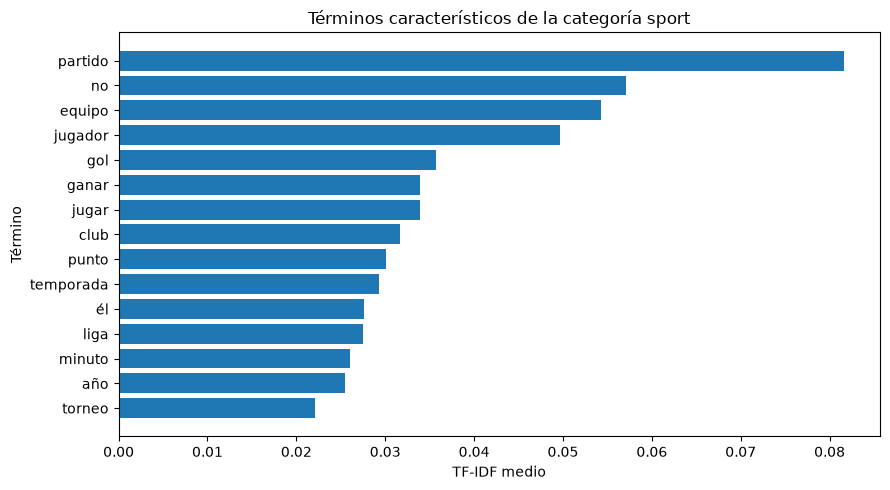

In [65]:
plt.figure(figsize=(9, 5))

plt.barh(
    top_sport["termino"][::-1],
    top_sport["tfidf_medio"][::-1]
)

plt.xlabel("TF-IDF medio")
plt.ylabel("Término")
plt.title("Términos característicos de la categoría sport")
plt.tight_layout()
plt.show()

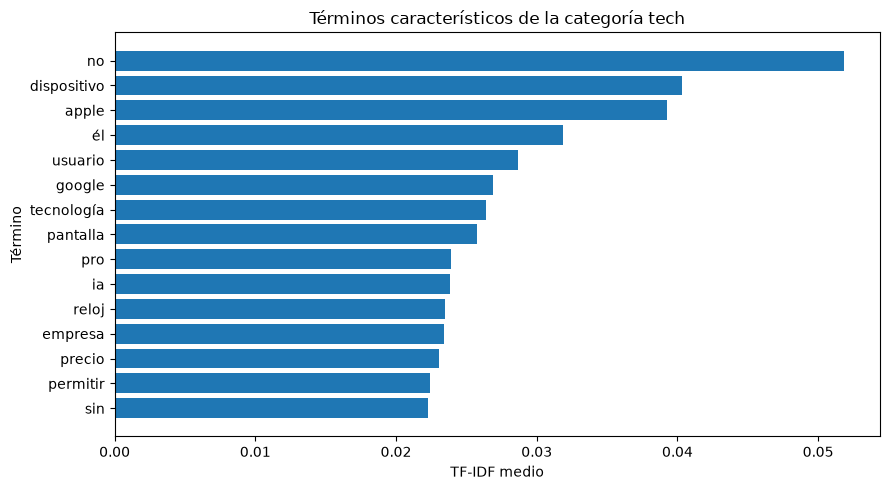

In [66]:
plt.figure(figsize=(9, 5))

plt.barh(
    top_tech["termino"][::-1],
    top_tech["tfidf_medio"][::-1]
)

plt.xlabel("TF-IDF medio")
plt.ylabel("Término")
plt.title("Términos característicos de la categoría tech")
plt.tight_layout()
plt.show()

### Comparación temática entre `sport` y `tech`

Los términos con mayor TF-IDF muestran diferencias claras entre ambas
categorías.

En `sport` destacan términos relacionados con competición y fútbol, como
`partido`, `equipo`, `jugador`, `gol`, `liga` y `torneo`.

En `tech` aparecen términos vinculados a productos y servicios tecnológicos,
como `dispositivo`, `apple`, `usuario`, `google`, `tecnología`, `pantalla`
e `ia`.

Esta separación léxica constituye una primera señal de que el contenido
textual puede utilizarse para identificar el contexto temático de una página,
lo que posteriormente permitiría asociarlo con categorías publicitarias.

In [67]:
terminos_sport = set(top_sport["termino"])
terminos_tech = set(top_tech["termino"])

comunes = terminos_sport.intersection(terminos_tech)

porcentaje_solapamiento = (
    len(comunes) / 15 * 100
)

print("Términos comunes:", comunes)
print("Número de términos comunes:", len(comunes))
print(f"Solapamiento sobre el top 15: {porcentaje_solapamiento:.1f}%")

Términos comunes: {'él', 'no'}
Número de términos comunes: 2
Solapamiento sobre el top 15: 13.3%


In [68]:
resumen_temas = {}

for categoria in sorted(df["category"].unique()):
    top = terminos_categoria(categoria, 5)
    resumen_temas[categoria] = top["termino"].tolist()

pd.DataFrame.from_dict(
    resumen_temas,
    orient="index",
    columns=["Término 1", "Término 2", "Término 3", "Término 4", "Término 5"]
)

,Término 1,Término 2,Término 3,Término 4,Término 5
alimentation,|,receta,dap,cocina,no
astronomy,espacial,estrella,suscriptor,planeta,tierra
economy,euros,millón,año,españa,precio
fashion,vestido,prenda,moda,look,euros
medicine,paciente,enfermedad,arterial,the,of
military,sistema,defensa,capacidad,militar,avión
motor,coche,eléctrico,motor,no,vehículo
play,película,no,cine,espinof,estreno
politics,gobierno,pp,no,milei,feijóo
religion,papa,iglesia,dios,no,francisco


### Hallazgo principal del análisis exploratorio

La comparación de los 15 términos con mayor TF-IDF de las categorías
`sport` y `tech` muestra un solapamiento reducido.

Solo 2 de los 15 términos aparecen en ambas categorías (`no` y `él`),
lo que representa un solapamiento del 13,3 %.

El 86,7 % restante de los términos principales es diferente entre ambas
categorías.

Esta diferenciación léxica constituye una primera evidencia de que el
contenido textual permite distinguir contextos temáticos diferentes, lo que
resulta relevante para el objetivo final del proyecto: seleccionar publicidad
en función del contexto semántico de una página web.

### Primera señal de temas

Los términos con mayor TF-IDF por categoría muestran una asociación clara
con las temáticas originales del corpus.

Por ejemplo, `sport` presenta términos como `partido`, `equipo`, `jugador`
y `gol`, mientras que `tech` contiene `dispositivo`, `apple` y `usuario`.
Del mismo modo, categorías como `fashion`, `motor`, `religion` y
`astronomy` presentan vocabularios propios fácilmente interpretables.

Esto aporta una primera señal de que las categorías contienen patrones
lingüísticos diferenciados que podrían aprovecharse posteriormente para
clasificar el contexto de una página web.

- Aunque el corpus está etiquetado como español, el análisis exploratorio
  detecta algunos términos residuales en inglés y tokens anómalos, como
  `the`, `of` o `|`. Esto sugiere que determinados documentos contienen
  fragmentos no normalizados y constituye una limitación de calidad del corpus.

## 5. Limitaciones

### Sesgos de la fuente

El corpus procede de un dataset de noticias y, por tanto, representa
principalmente lenguaje periodístico. Los resultados pueden no generalizar
directamente a otros tipos de páginas web como blogs, tiendas online,
foros o páginas corporativas.

Además, las categorías están prácticamente balanceadas, con aproximadamente
170 documentos por categoría. Esta distribución es útil para el análisis,
pero no representa necesariamente la frecuencia real de estos temas en Internet.

### Calidad del texto

Se han detectado algunos términos residuales en otros idiomas y tokens
anómalos después del preprocesamiento, lo que indica que existen documentos
con contenido parcialmente no normalizado.

También se ha identificado un documento extremadamente largo de la categoría
`medicine` con 29.746 palabras. Su contenido parece coherente, por lo que se
ha conservado, aunque puede afectar determinadas estadísticas de longitud.

### Preguntas que el corpus no permite responder

El corpus permite estudiar si existen diferencias lingüísticas entre
categorías temáticas, pero no permite determinar qué anuncio tendría una
mayor tasa de clic, conversión o rentabilidad.

Tampoco contiene información sobre los usuarios que visitan las páginas,
ya que el proyecto se centra exclusivamente en publicidad contextual.

### Riesgos para los siguientes hitos

Una categoría temática por sí sola puede ser insuficiente para determinar
si un anuncio es apropiado. Dos artículos de la misma categoría pueden tener
tonos o contextos muy diferentes.

En los siguientes hitos será necesario estudiar representaciones semánticas
más avanzadas y valorar cómo incorporar elementos como tono, contexto y
similitud con las categorías publicitarias.